In [9]:
### IMPORTS ###

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
### DATA CLEANING ###

In [11]:
# read in data
diseases = pd.read_csv("diseases.csv")

# first look at data
print(diseases.head())
print(diseases.columns)

# data types
diseases.dtypes

     Disease   County  Year     Sex  Cases  Population    Rate  Lower_95__CI  \
0  Amebiasis  Alameda  2001  Female    7.0      746596  0.938*         0.377   
1  Amebiasis  Alameda  2001    Male    9.0      718968  1.252*         0.572   
2  Amebiasis  Alameda  2001   Total   16.0     1465564  1.092*         0.624   
3  Amebiasis  Alameda  2002  Female    4.0      747987  0.535*         0.146   
4  Amebiasis  Alameda  2002    Male    5.0      720481  0.694*         0.225   

   Upper_95__CI  
0         1.932  
1         2.376  
2         1.773  
3         1.369  
4         1.620  
Index(['Disease', 'County', 'Year', 'Sex', 'Cases', 'Population', 'Rate',
       'Lower_95__CI', 'Upper_95__CI'],
      dtype='object')


Disease          object
County           object
Year              int64
Sex              object
Cases           float64
Population        int64
Rate             object
Lower_95__CI    float64
Upper_95__CI    float64
dtype: object

In [22]:
# remove "Other" diseases
diseases = diseases[diseases["Disease"] != "Other"].copy()

# clean "Rate"
diseases["Rate"] = (
    diseases["Rate"]
    .str.replace("*", "", regex=False)
)

# convert invalid strings to NaN
diseases["Rate"] = pd.to_numeric(
    diseases["Rate"],
    errors="coerce"
)

# OPTIONAL: if we only want county-level analysis, remove 'California' values
diseases = diseases[diseases["County"] != "California"].copy()

In [23]:
# missing values
print(diseases["Rate"].isna().sum())

129803


In [24]:
# a HUGE amount of rate values are missing, but we can calculate it ourselves and replace the column

# recompute rate
diseases["Rate"] = (
    diseases["Cases"] * 100000 / diseases["Population"]
)

In [27]:
# new missing values
print(diseases["Rate"].isna().sum())

4120


In [29]:
### EDA ###

In [30]:
# dataset overview

print("shape:", diseases.shape)

print("\ncolumns:")
print(diseases.columns)

print("\ndata types:")
print(diseases.dtypes)

print("\nmissing values:")
print(diseases.isnull().sum())

print("\nyears covered:")
print(diseases["Year"].min(), "-", diseases["Year"].max())

print("\nnumber of diseases:")
print(diseases["Disease"].nunique())

print("\nnumber of counties:")
print(diseases["County"].nunique())

print("\nsex categories:")
print(diseases["Sex"].unique())

shape: (161646, 9)

columns:
Index(['Disease', 'County', 'Year', 'Sex', 'Cases', 'Population', 'Rate',
       'Lower_95__CI', 'Upper_95__CI'],
      dtype='object')

data types:
Disease          object
County           object
Year              int64
Sex              object
Cases           float64
Population        int64
Rate            float64
Lower_95__CI    float64
Upper_95__CI    float64
dtype: object

missing values:
Disease            0
County             0
Year               0
Sex                0
Cases           4120
Population         0
Rate            4120
Lower_95__CI    4966
Upper_95__CI    4966
dtype: int64

years covered:
2001 - 2019

number of diseases:
53

number of counties:
58

sex categories:
['Female' 'Male' 'Total']


In [31]:
# summary statistics

print(
    diseases[["Cases", "Population", "Rate"]]
    .describe()
)

               Cases    Population           Rate
count  157526.000000  1.616460e+05  157526.000000
mean        5.398829  4.313309e+05       1.038908
std        44.770313  1.018689e+06       6.446154
min         0.000000  5.630000e+02       0.000000
25%         0.000000  2.855900e+04       0.000000
50%         0.000000  1.139990e+05       0.000000
75%         0.000000  4.085990e+05       0.000000
max      3371.000000  1.026994e+07     405.723191


Disease
Campylobacteriosis                                  256781.0
Salmonellosis                                       181751.0
Coccidioidomycosis                                  146972.0
Giardiasis                                           82134.0
Shigellosis                                          72397.0
Shiga toxin-producing E. coli (STEC) without HUS     26872.0
Cryptosporidiosis                                    14171.0
Amebiasis                                            13582.0
Legionellosis                                         9469.0
Vibrio Infection (non-Cholera)                        6051.0
Malaria                                               4928.0
Yersiniosis                                           4604.0
Listeriosis                                           4173.0
Lyme Disease                                          3637.0
Typhoid Fever, case                                   2854.0
Name: Cases, dtype: float64


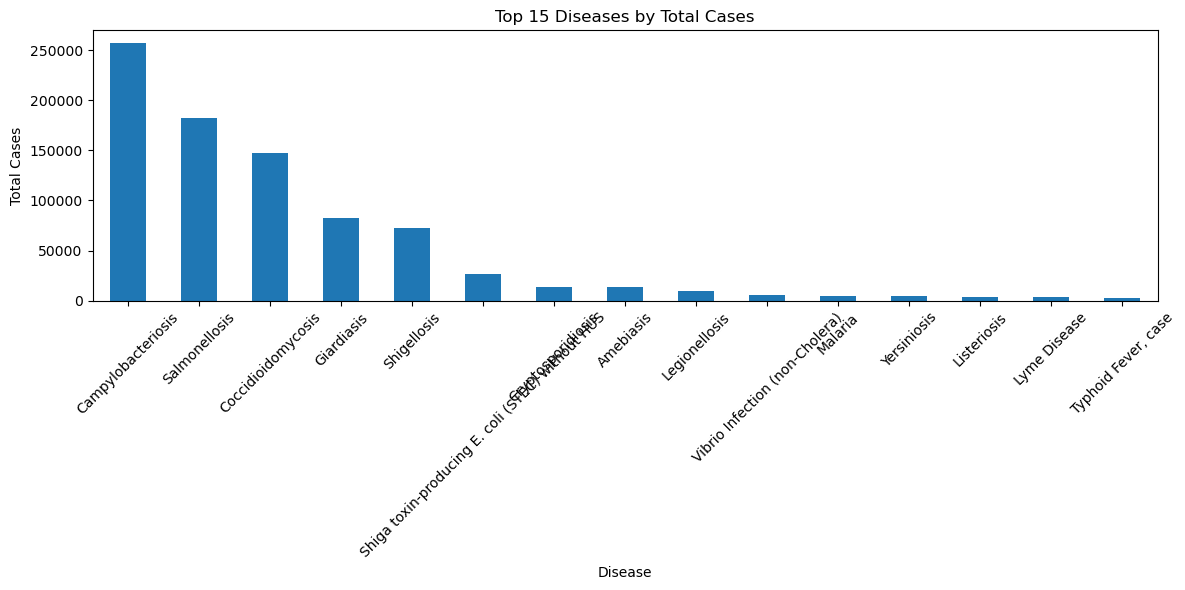

In [33]:
# total cases by disease
disease_totals = (
    diseases.groupby("Disease")["Cases"]
    .sum()
    .sort_values(ascending=False)
)

print(disease_totals.head(15))

# top diseases
top_diseases = disease_totals.head(15)

plt.figure(figsize=(12,6))

top_diseases.plot(kind="bar")

plt.title("Top 15 Diseases by Total Cases")
plt.ylabel("Total Cases")
plt.xlabel("Disease")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

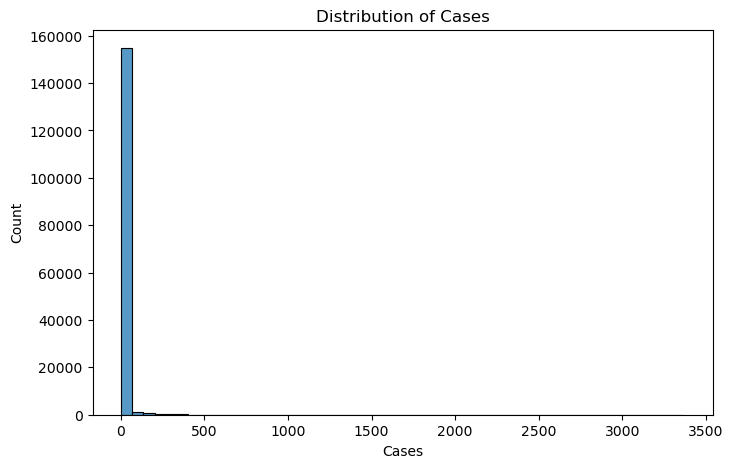

In [34]:
# distribution of cases

plt.figure(figsize=(8,5))

sns.histplot(diseases["Cases"], bins=50)

plt.title("Distribution of Cases")
plt.xlabel("Cases")

plt.show()

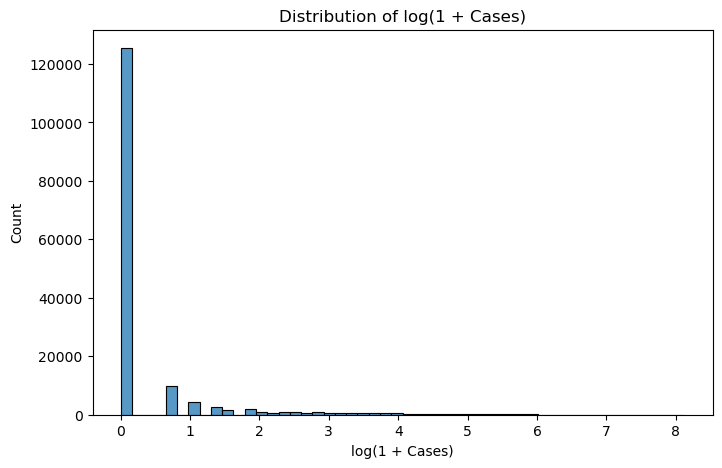

In [35]:
# log cases

plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(diseases["Cases"]),
    bins=50
)

plt.title("Distribution of log(1 + Cases)")
plt.xlabel("log(1 + Cases)")

plt.show()

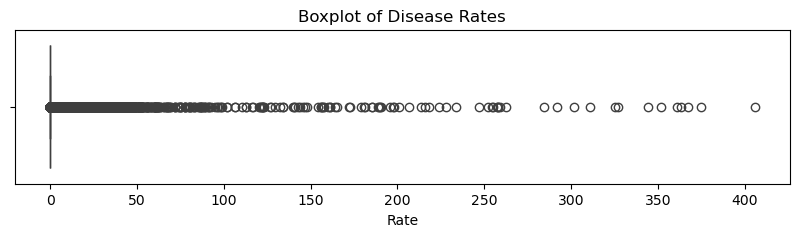

In [38]:
# distribution of rates
plt.figure(figsize=(10,2))

sns.boxplot(
    x=diseases["Rate"]
)

plt.title("Boxplot of Disease Rates")

plt.show()

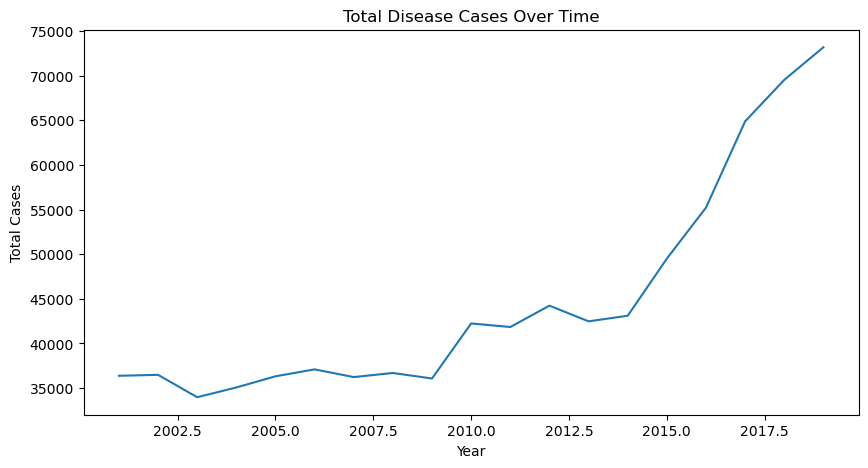

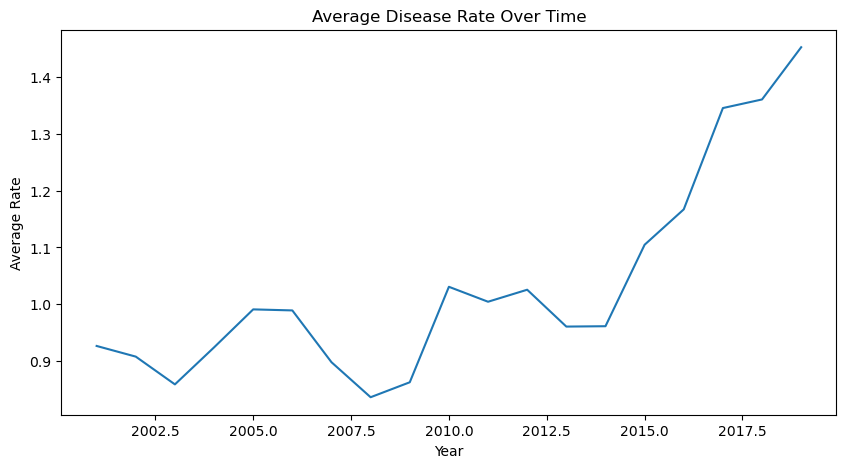

In [39]:
# trends over time
yearly_cases = (
    diseases.groupby("Year")["Cases"]
    .sum()
)

plt.figure(figsize=(10,5))

plt.plot(
    yearly_cases.index,
    yearly_cases.values
)

plt.title("Total Disease Cases Over Time")
plt.xlabel("Year")
plt.ylabel("Total Cases")

plt.show()

yearly_rates = (
    diseases.groupby("Year")["Rate"]
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    yearly_rates.index,
    yearly_rates.values
)

plt.title("Average Disease Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rate")

plt.show()

In [40]:
# county-level

county_rates = (
    diseases.groupby("County")["Rate"]
    .mean()
    .sort_values(ascending=False)
)

print(county_rates.head(15))

County
Kern               4.944694
Kings              2.923126
San Francisco      2.602451
Fresno             2.133497
San Luis Obispo    2.125976
Tulare             2.118383
Madera             1.766057
Marin              1.639496
San Mateo          1.599200
San Joaquin        1.536210
Merced             1.501804
Napa               1.455229
Imperial           1.441910
Stanislaus         1.438319
Alameda            1.389063
Name: Rate, dtype: float64


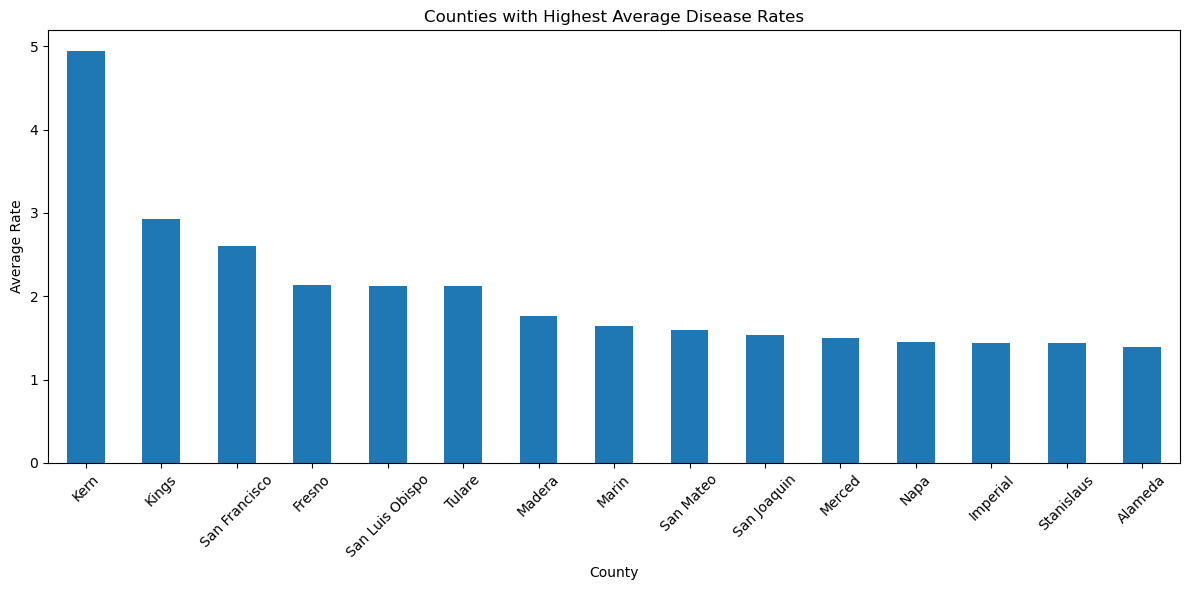

In [41]:
top_counties = county_rates.head(15)

plt.figure(figsize=(12,6))

top_counties.plot(kind="bar")

plt.title("Counties with Highest Average Disease Rates")
plt.xlabel("County")
plt.ylabel("Average Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sex
Female    0.816119
Male      1.043737
Total     1.248535
Name: Rate, dtype: float64


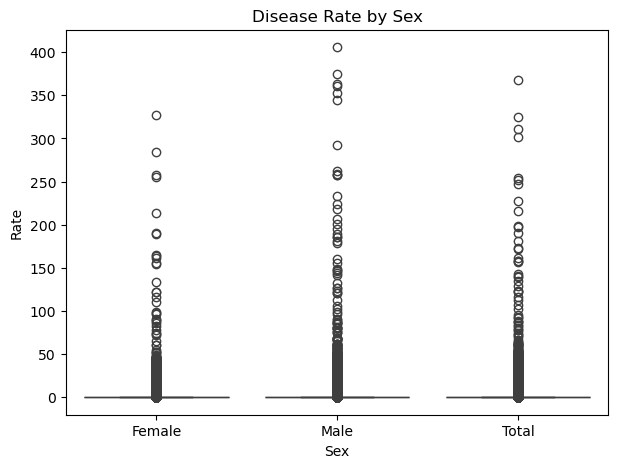

In [42]:
# by sex

sex_rates = (
    diseases.groupby("Sex")["Rate"]
    .mean()
)

print(sex_rates)

plt.figure(figsize=(7,5))

sns.boxplot(
    data=diseases,
    x="Sex",
    y="Rate"
)

plt.title("Disease Rate by Sex")
plt.ylabel("Rate")

plt.show()

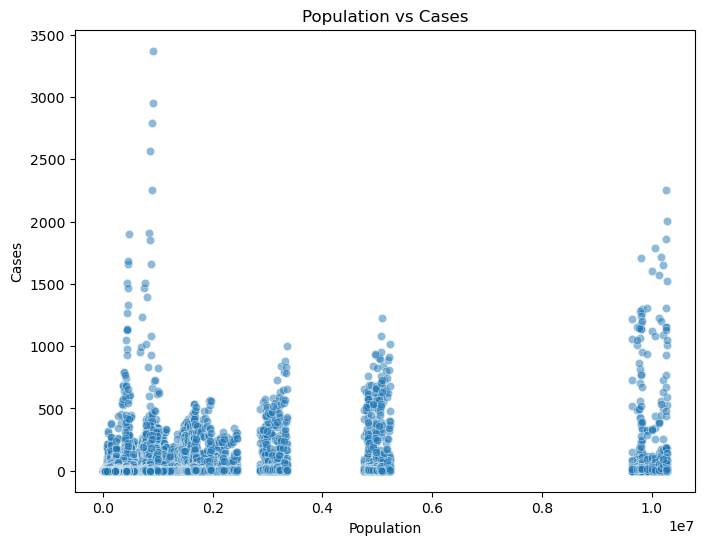

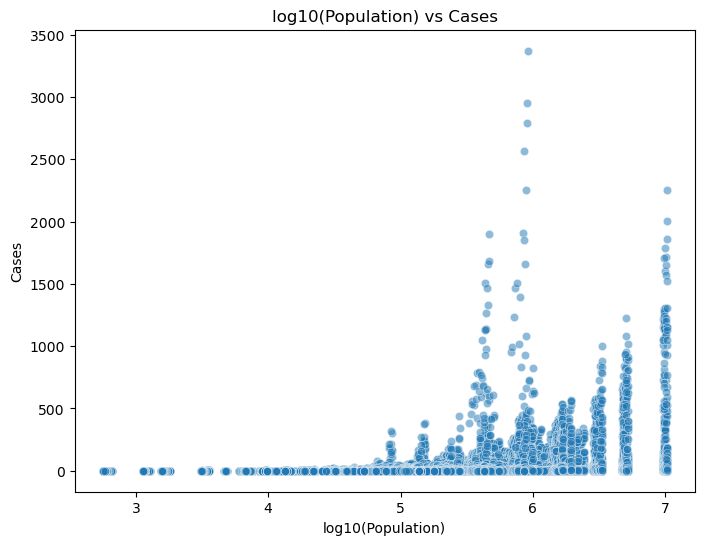

In [43]:
# by population

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=diseases,
    x="Population",
    y="Cases",
    alpha=0.5
)

plt.title("Population vs Cases")
plt.xlabel("Population")
plt.ylabel("Cases")

plt.show()

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=np.log10(diseases["Population"]),
    y=diseases["Cases"],
    alpha=0.5
)

plt.title("log10(Population) vs Cases")
plt.xlabel("log10(Population)")
plt.ylabel("Cases")

plt.show()

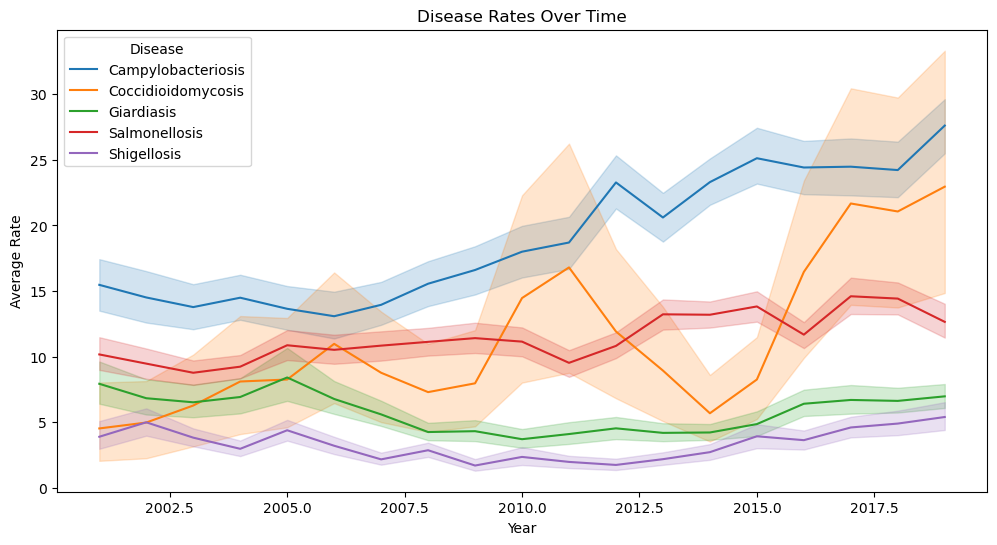

In [44]:
# disease over time (top 5)

top5 = disease_totals.head(5).index

top5_df = diseases[
    diseases["Disease"].isin(top5)
]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=top5_df,
    x="Year",
    y="Rate",
    hue="Disease",
    estimator="mean"
)

plt.title("Disease Rates Over Time")
plt.ylabel("Average Rate")

plt.show()

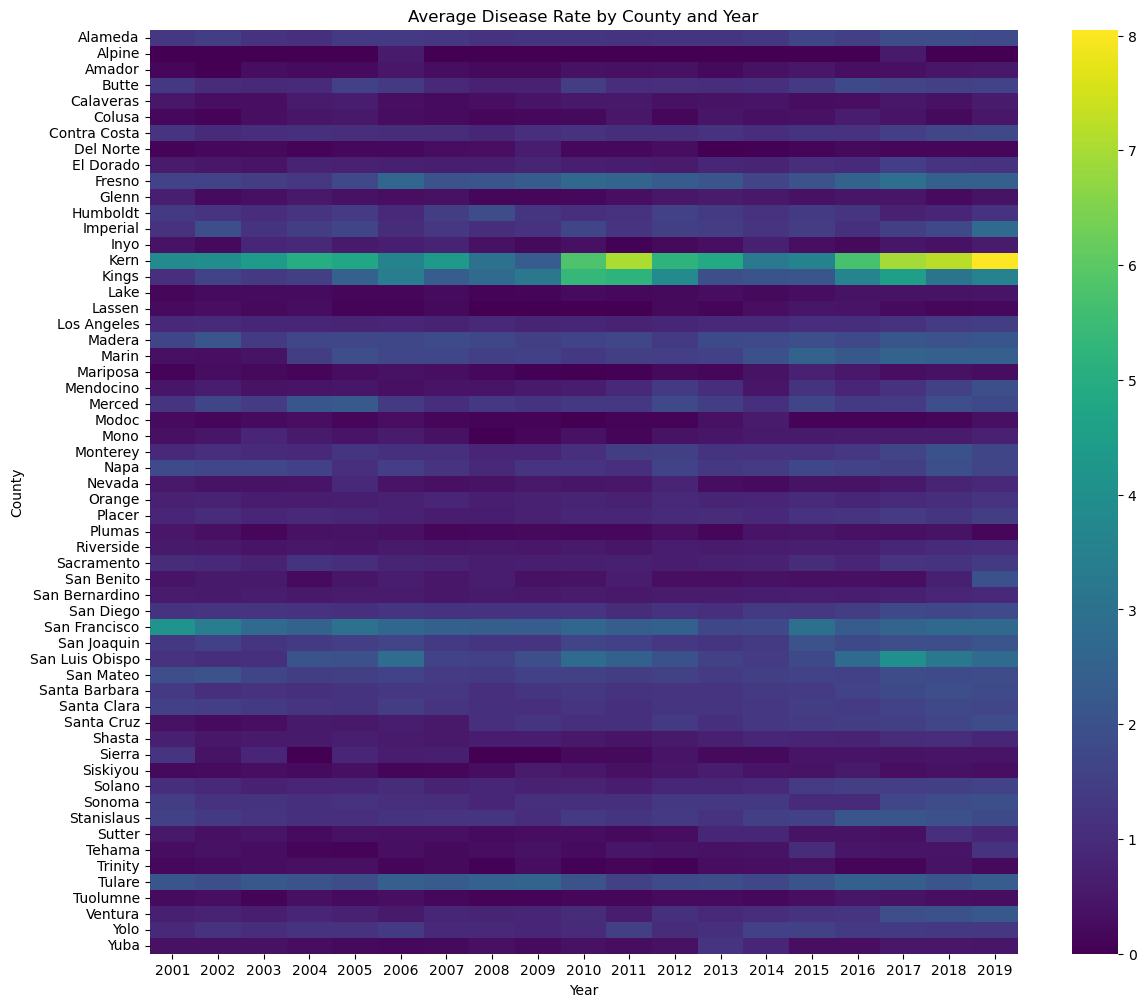

In [45]:
# country-year heatmap

county_year = (
    diseases.groupby(["County", "Year"])["Rate"]
    .mean()
    .reset_index()
)

heatmap_data = county_year.pivot(
    index="County",
    columns="Year",
    values="Rate"
)

plt.figure(figsize=(14,12))

sns.heatmap(
    heatmap_data,
    cmap="viridis"
)

plt.title("Average Disease Rate by County and Year")

plt.show()